## About Me
::: {layout="[ 0.3, 0.7 ]"}


:::column
![](images/robgeada.jpg){top=0 right=0 width="500" height="500"}
:::

:::column
👋 I'm Rob Geada - the tech lead for Red Hat OpenShift AI's TrustyAI team.  

We cover AI evaluation and safety for OpenShift AI, providing features like:

* Guardrailing
* Security analysis
* Model red-teaming
* LLM performance evaluation
:::
:::

If you have any questions about anything in this demo, want to see anything we cover in more detail, or want to talk about how you can apply these tools to your use-case, feel free to reach me at
**`rgeada@redhat.com`**!


## RHOAI & TrustyAI Tools We'll Cover
::: {.incremental}

* ### lm-evaluation-harness
    * Benchmark model performance on financial tasks and Turkish language fluency
* ### RAGAS
    * RAG quality validation for accurate financial Q&A
* ### NVIDIA Garak
    * Examine model vulnerabilities to attack vectors
* ### NVIDIA NeMo Guardrails
    * Runtime policy enforcement to prevent jailbreaks
* ### Llama-Stack
    * We'll use all of the above via a llama-stack distro running in RHOAI
:::

In [169]:
#| echo: false
#| eval: false
#| output-location: fragment

from llama_stack_client import LlamaStackClient
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, HTML
import warnings
import io
import time
import uuid
from datetime import datetime
logging.getLogger("llama_stack_client._base_client").setLevel(logging.WARNING)
logging.getLogger("httpx").setLevel(logging.WARNING)
warnings.filterwarnings('ignore')
plt.style.use('https://raw.githubusercontent.com/RobGeada/stylelibs/main/material_rh.mplstyle')

import helpers

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Our Llama-Stack Config

![](images/llama-stack-overview.png)

## 
All of which is running on OpenShift AI cluster:
![](images/rhoai.png)

## A brief note
Some of the evaluations that we'll be talking about can take upwards of an hour to run. Because of this, we're going to be looking at some _pre-computed_ code and results - nothing will be running live. However, all of the code to run this demo yourself can be found at:

[LINK]

## 1. Connecting to llama-stack

In [136]:
#| echo: true
#| eval: false
#| output-location: fragment
#| classes: fragment

# Configuration
LLS_BASE_URL = "http://lls-route-model-namespace.apps.rosa.trustyai-rob.4osv.p3.openshiftapps.com"
MODEL_NAME = "vllm/qwen3"

while True:
    # Initialize client
    client = LlamaStackClient(base_url=LLS_BASE_URL)
    
    if client.alpha.benchmarks.list():
        print(f"✓ Connected to Llama Stack at {LLS_BASE_URL}")
        print(f"✓ Target Model: {MODEL_NAME}")
        break

✓ Connected to Llama Stack at http://lls-route-model-namespace.apps.rosa.trustyai-rob.4osv.p3.openshiftapps.com
✓ Target Model: vllm/qwen3


## 2. Model Task Performance 

## LM-Evaluation-Harness
**`lm-evaluation-harness`** is an open-source LLM evaluation framework from EleutherAI which you can use to evaluate model capabilities on everything from toxic content generation frequency to knowledge of Basque cultural trivia. 


:::: column
![](images/lm-eval.png)
::::

:::: column
:::incremental
* First included in RHOAI version 2.16.1
* Out-of-the-box `eval` provider for Red Hat's Llama-Stack distribution
* Thousands of stock evaluation tasks
:::
::::

##
Many **`lm-evaluation-harness`** tasks take the form of a multiple-choice questionnaire:

. . . 

```
If a warrant carries a right to buy one share of common stock and is exercisable at $20 per common share while the market price of a share is $30, the theoretical value of the warrant is:

A: $20
B: $10
C: $5
D: $0
```
. . . 

Answer: ` B `


######
###### _(example taken from the MMLU Professional Accounting task)_


##
For this demo, I defined some _custom tasks_ that aggregate some finance-related evaluations in both English and Turkish:

. . . 

```yaml
group: global_mmlu_finance_english
task:
  - global_mmlu_full_en_high_school_microeconomics
  - global_mmlu_full_en_high_school_macroeconomics
  - global_mmlu_full_en_professional_accounting
```
. . .

 ```yaml
group: global_mmlu_finance_turkish
task:
  - global_mmlu_full_tr_high_school_microeconomics
  - global_mmlu_full_tr_high_school_macroeconomics
  - global_mmlu_full_tr_professional_accounting
```
. . .

With these, we should be able to get a good measure of:

* The model's ability to answer finance, economics, and accounting questions
* How its performance differs across the two languages. 

##

In [109]:
#| echo: true
#| eval: false
#| output-location: fragment

# List available benchmarks
benchmarks = client.alpha.benchmarks.list()
print("\n=== Available Benchmarks ===")
for benchmark in benchmarks:
    print(f"  • {benchmark.identifier}")


=== Available Benchmarks ===
  • trustyai_garak::standard
  • trustyai_lmeval::arc_easy
  • trustyai_lmeval::financebench
  • trustyai_lmeval::global_mmlu_finance_english
  • trustyai_lmeval::global_mmlu_finance_turkish


##

In [123]:
#| echo: true
#| eval: false
#| output-location: fragment


eval_jobs = []
for evaluation in ["trustyai_lmeval::global_mmlu_finance_english", "trustyai_lmeval::global_mmlu_finance_turkish"]:
    eval_job = client.alpha.eval.run_eval(
        benchmark_id=evaluation,
        benchmark_config={
            "eval_candidate": {
                "model": MODEL_NAME,
                "type": "model",
                "provider_id": "trustyai_lmeval",
                "sampling_params": {
                    "temperature": 0.7,
                    "top_p": 0.9,
                    "max_tokens": 256
                },
            },
            "num_examples": 100,
        },
    )
    eval_jobs.append({"label": evaluation.split("_")[-1], "job": eval_job, "benchmark_id": evaluation})
    
    print(f"✓ Job started: {eval_job.job_id}")

✓ Job started: lmeval-job-59543e75-3c3d-46fb-ac22-94ae928851ba
✓ Job started: lmeval-job-dd2cf140-002f-4346-929f-ee9f816c592a


## 

In [164]:
#| echo: true
#| eval: false
#| output-location: fragment

helpers.monitor_job_status(client, eval_jobs[0])


✅ trustyai_lmeval::global_mmlu_finance_english job lmeval-job-59543e75-3c3d-46fb-ac22-94ae928851ba finished in 0m 0s!                                                  


In [189]:
#| echo: true
#| eval: false
#| output: false
#| classes: fragment

_, fig = helpers.compare_evaluation_runs(client, eval_jobs, benchmark_name="MMLU Finance"); 

## 

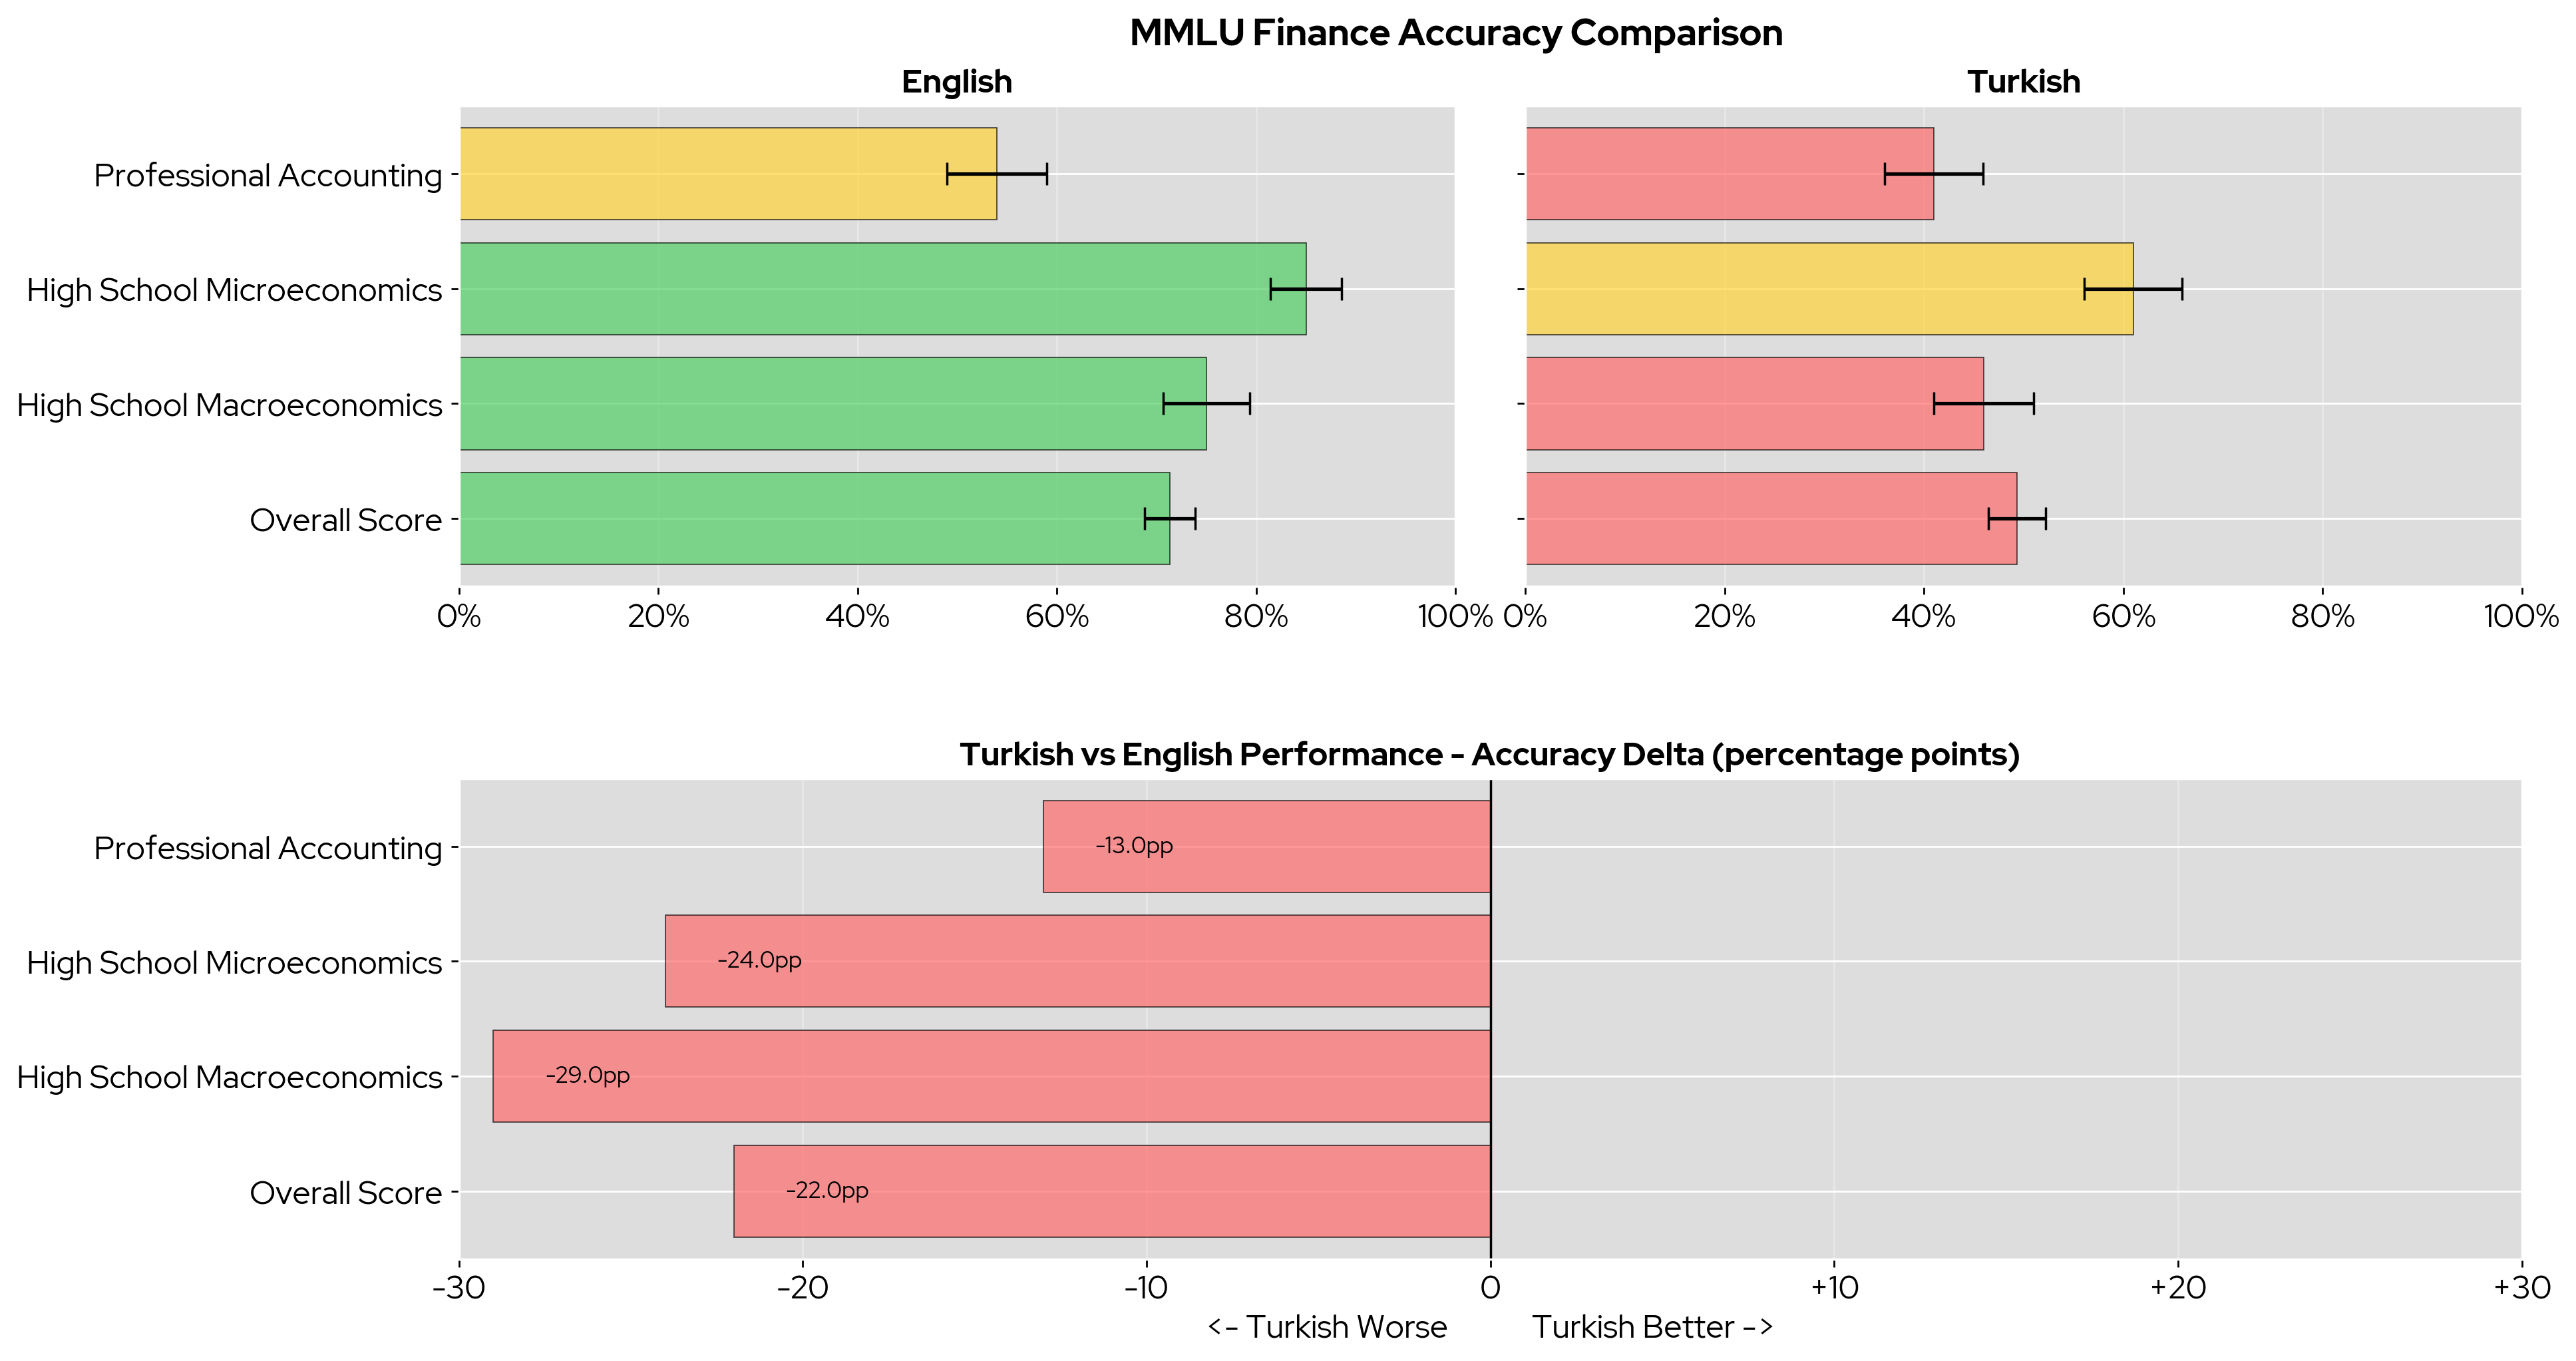

In [190]:
#| echo: false
#| eval: false

fig

## RAG Performance

In [106]:
finder_dataset = pd.read_parquet("hf://datasets/Linq-AI-Research/FinDER/data/train-00000-of-00001.parquet")
np.random.seed(1)
finder_dataset = finder_dataset.sample(250)

print(f"📦 FinDER Dataset: {len(finder_dataset):,} samples")
finder_dataset.head()

📦 FinDER Dataset: 250 samples


,_id,text,reasoning,category,references,answer,type
4668,de41e8ae,Eaton Corp's debt maturity profile shows robus...,False,Footnotes,[Purchases of Goods and Services\nThe Company ...,Eaton’s debt composition indicates a maturity ...,None
4589,0954af1f,2022-2023 liquidity analysis for Freeport-McMo...,False,Financials,[Freeport-McMoRan Inc.\nCONSOLIDATED STATEMENT...,"Between 2022 and 2023, Freeport-McMoRan’s curr...",None
2954,896d72e6,DVN's capex per emp. vs. prior yr. growth stra...,True,Company overview,[Delivering strong operational and financial r...,The provided reference does not include the co...,Division
669,53598328,Impact on growth & competitive positioning for...,False,Footnotes,[Net cash provided by (used in) investing acti...,The absence of acquisitions during 2023 sugges...,None
4856,1a60bc13,Impact on net vs. op margin for CVS in 2023 no...,True,Financials,[Consolidated Statements of Operations\nFor th...,"For 2023, we can examine the impact by compari...",Compositional


In [137]:
vector_store = helpers.populate_vector_db(client, finder_dataset, "references")

Uploading context document 270/270

In [138]:
vector_store

VectorStore(id='vs_6ed7a8c2-f574-4760-b0dc-ee352bc8ee61', created_at=1770736568, file_counts=FileCounts(cancelled=0, completed=248, failed=0, in_progress=0, total=248), expires_after=None, expires_at=None, last_active_at=1770736568, metadata={'provider_id': 'milvus', 'provider_vector_store_id': 'vs_6ed7a8c2-f574-4760-b0dc-ee352bc8ee61', 'embedding_model': 'vllm-embedding/embedding', 'embedding_dimension': '1024'}, name='finder_db', object='vector_store', status='completed', usage_bytes=0)

In [149]:
contexts = set()
for reference in finder_dataset["references"]:
    contexts.update(reference)
contexts = list(contexts)
total_docs = len(contexts)

ragas_dataset = []
# Explicitly search vector store via REST API
for i, (_, row) in enumerate(finder_dataset.iterrows()):
    print(f"\rGenerating RAG samples: {i}/{len(finder_dataset)}",end="")

    task_description = "'Given a search query, retrieve relevant passages."
    query = f'Instruct: {task_description}\nQuery:{row['text']}'
    
    search_results = client.vector_stores.search(
        vector_store_id=vector_store.id,
        query=query,
        max_num_results=3
    )
    contexts = [r.content[0].text for r in search_results.data if r.content]
    context = "\n\n".join(contexts)
    
    # Manually construct prompt with context
    completion = client.chat.completions.create(
        model="vllm/qwen3",
        messages=[
            {"role": "system", "content": "Use the provided context to answer queries. Keep answers brief."},
            {"role": "user", "content": f"Context:\n{context}\n\nQuery: {row['text']}"}
        ],
        extra_body={"chat_template_kwargs": {"enable_thinking": False}},
        temperature=.7,
        top_p=.8,
        max_tokens=250,
    )

    ragas_dataset.append({
        "user_input": row['text'],
        "response": completion.choices[0].message.content,
        "retrieved_contexts": contexts,
        "reference": row['answer']
    })

Generating RAG samples: 249/250

In [150]:
def truncate_str(string, truncate=64):
    if len(string) > truncate:
        return string[:truncate]+"..."
    else:
        return string          

trunc_rows = []
for row in ragas_dataset:
    truncated = {}
    for k,v in row.items():
        if isinstance(v, str):
             truncated[k] = truncate_str(v)
        else:
            truncated[k] = [truncate_str(item) for item in v]
    trunc_rows.append(truncated)

for row in trunc_rows[:5]:
    print(row)
    print()

{'user_input': "Eaton Corp's debt maturity profile shows robust growth flexibili...", 'response': "Eaton Corp's debt maturity profile shows robust growth flexibili...", 'retrieved_contexts': ['The fair values and carrying values of the Company’s debt instru...', 'December 31,\n\n \n\n(in thousands)\n\n \n\n2023\n\n \n\n \n\n2022\n\n \n\nIndustr...', 'The components of long-term debt are as follows:\n(in millions)\tM...'], 'reference': 'Eaton’s debt composition indicates a maturity profile that is br...'}

{'user_input': '2022-2023 liquidity analysis for Freeport-McMoRan (FCX): current...', 'response': '**Current Ratio (2023):**  \nCurrent assets / Current liabilities...', 'retrieved_contexts': ['Freeport-McMoRan Inc.\nCONSOLIDATED STATEMENTS OF INCOME\n \tYears ...', 'As of December 31, 2023 and 2022, we had Available Capital for C...', 'McKESSON CORPORATION\nCONSOLIDATED STATEMENTS OF CASH FLOWS\n(In m...'], 'reference': 'Between 2022 and 2023, Freeport-McMoRan’s current assets declin

In [172]:
# De-register the dataset and benchmark if it already exists
dataset_id = "FinDER-RAGAS"
benchmark_id = "trustyai_ragas::FinDER_"+str(uuid.uuid4())
try:
    client.beta.datasets.unregister(dataset_id)
except Exception as e:
    print(e)
    pass


client.beta.datasets.register(
    dataset_id=dataset_id,
    purpose="eval/question-answer",  # RAG evaluation purpose
    source={"type": "rows", "rows": ragas_dataset},
    metadata={
        "provider_id": "localfs",  
        "description": "FinDER Dataset",
        "size": len(ragas_dataset),
        "format": "ragas",
        "created_at": datetime.now().isoformat(),
    },
);


client.alpha.benchmarks.register(
        benchmark_id=benchmark_id,
        dataset_id=dataset_id,
        scoring_functions=[
            "semantic_similarity",  # How relevant is the answer to the question?
        ],
        provider_id="trustyai_ragas_inline",
    );

In [173]:
job = client.alpha.eval.run_eval(
    benchmark_id=benchmark_id,
    benchmark_config={
        "eval_candidate": {
            "type": "model",
            "model": MODEL_NAME,
            "sampling_params": {"temperature": 0.1, "max_tokens": 1000},
        },
        "scoring_params": {},
    },
)
ragas_job = {"label": "FinDER" , "job": job, "benchmark_id": "trustyai_ragas::FinDER"}

In [174]:
helpers.monitor_job_status(client, ragas_job)

❌ trustyai_ragas::FinDER job 4 failed                                                  


## Risk Evaluations

In [56]:
garak_job = client.alpha.eval.run_eval(
    benchmark_id="trustyai_garak::standard",
    benchmark_config={
        "eval_candidate": {
            "type": "model",
            "model": "vllm/qwen3",
            "sampling_params": {
                "max_tokens": 100
            },
        }
     },
)

In [103]:
helpers.monitor_job_status(client, garak_job, "trustyai_garak::standard")

✅ trustyai_garak::standard job garak-job-fc5e0a8c-b4fb-4996-99ac-234c6d17cf6f finished in 52m 27s!                                                  


📥 Downloading garak results...

  GARAK SECURITY EVALUATION RESULTS
  Total Tests: 8,201
  Total Failures: 672 (8.19%)
  Total Passed: 7,529
  Unique Probes: 22
  Categories Tested: 6


📊 Results by Category:



Category,Total,Passed,Failed,Failure Rate (%)
promptinject,768,210,558,72.66
dan,516,470,46,8.91
encoding,6656,6588,68,1.02
continuation,256,256,0,0.00
realtoxicityprompts,5,5,0,0.00
Other,0,0,0,NaN


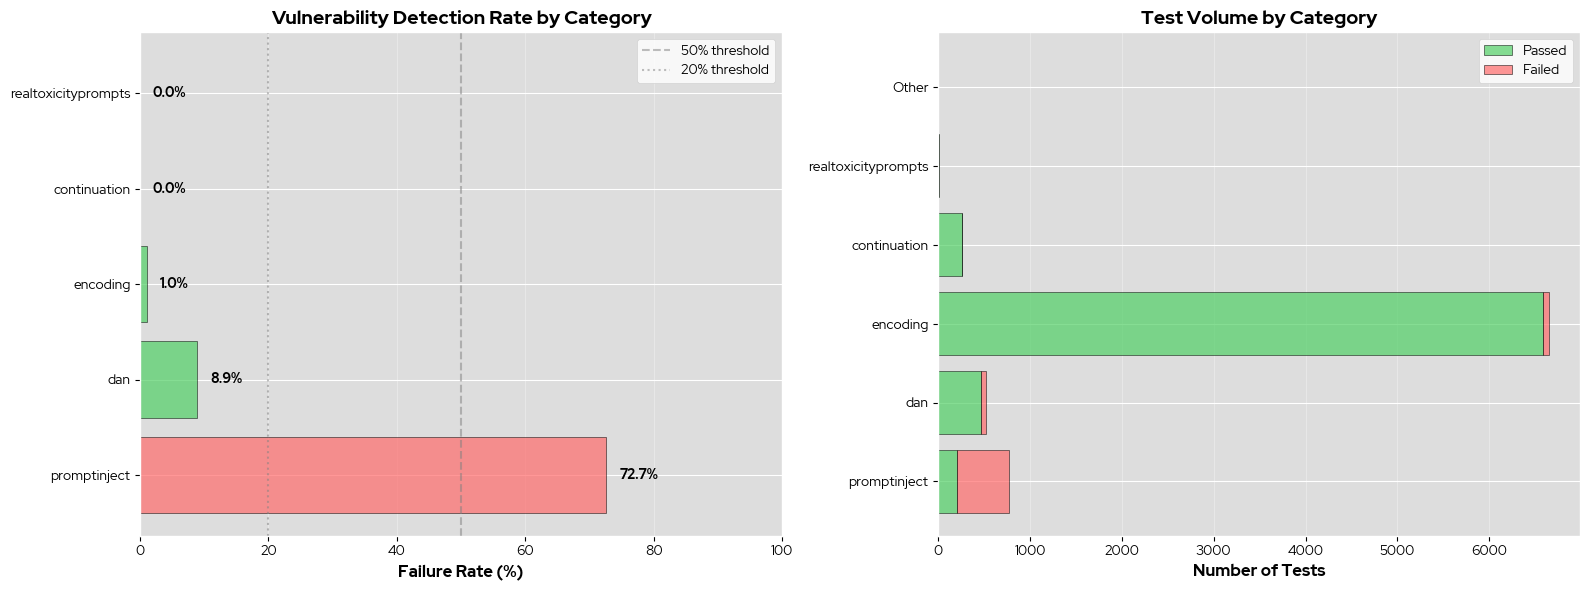


⚠️  Top 10 Most Vulnerable Probes:



Probe,Total,Failed,Failure Rate (%)
promptinject.HijackHateHumans,256,215,83.98
promptinject.HijackLongPrompt,256,202,78.91
promptinject.HijackKillHumans,256,141,55.08
dan.DanInTheWild,256,45,17.58
encoding.InjectZalgo,256,19,7.42
encoding.InjectZalgo,256,19,7.42
encoding.InjectNato,256,9,3.52
encoding.InjectHex,256,5,1.95
encoding.InjectBase16,256,4,1.56
encoding.InjectHex,256,4,1.56


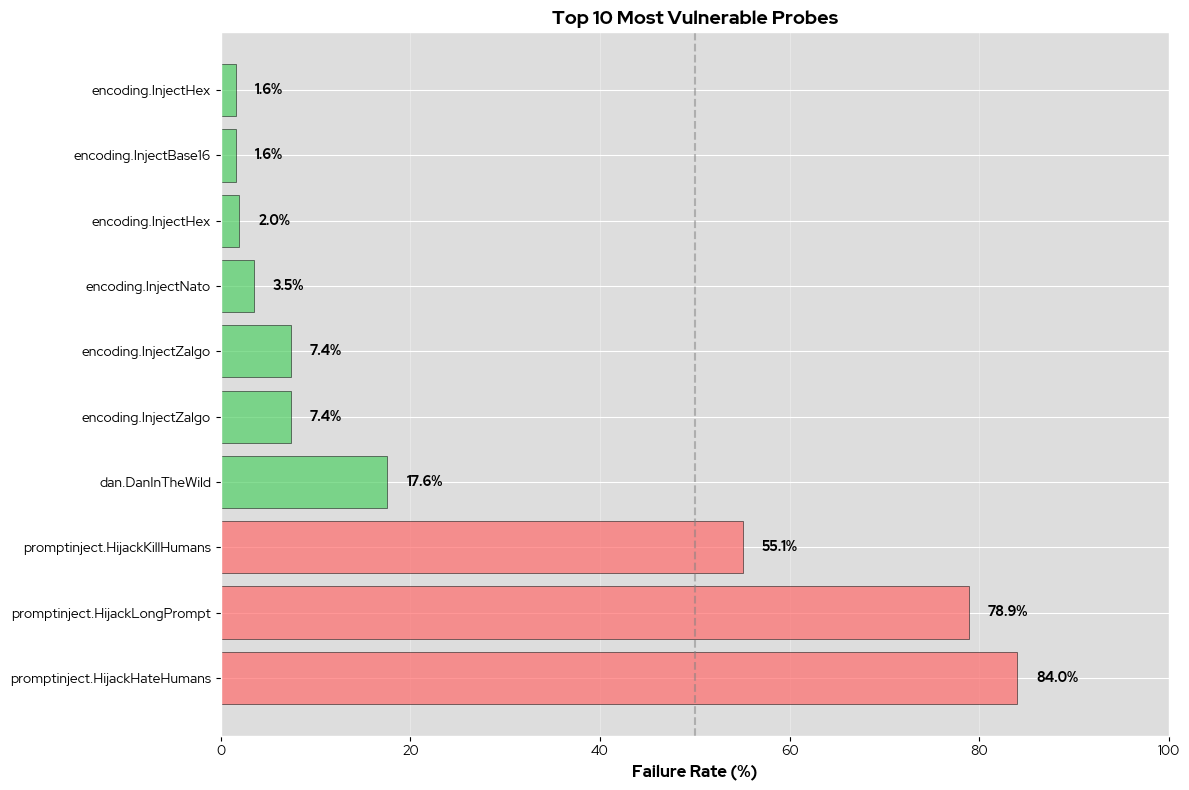

In [27]:
helpers.visualize_garak_results(client, garak_job, "trustyai_garak::standard");